<a href="https://colab.research.google.com/github/eoris1225/-fantasy/blob/main/%EC%99%84%EB%B2%BD%ED%95%9C_%ED%95%91%ED%95%91%EC%9D%84_%EC%9C%84%ED%95%9C_%EA%B3%BC%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# [셀 1/10] 설치 + 임포트
# ============================================================
!pip -q install "stable-baselines3[extra]" "sb3-contrib" gymnasium "gymnasium[box2d]" swig
!apt-get -qq install -y ffmpeg > /dev/null

import os, time, glob, re, random
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from collections import deque

from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, CallbackList
from stable_baselines3.common.utils import set_random_seed

In [ ]:
# ============================================================
# [셀 2/10] 구글 드라이브 마운트
# ============================================================
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/PingPing_Project"
    SAVE_DIR = os.path.join(base_path, "sb3_maskable_7games")
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"🐌 핑핑이 7게임 방 준비 완료!: {SAVE_DIR}")
else:
    SAVE_DIR = "/content/pingping_7games"
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"🐌 로컬 방 준비 완료!: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🐌 핑핑이 7게임 방 준비 완료!: /content/drive/MyDrive/PingPing_Project/sb3_maskable_7games


In [ ]:
# ============================================================
# [셀 3/10] 전역 설��� — 7게임
# ============================================================
SEED = 42
set_random_seed(SEED)

OBS_RAW_DIM = 8
NUM_GAMES = 7
OBS_TOTAL_DIM = OBS_RAW_DIM + NUM_GAMES  # 15
REWARD_CLIP = 10.0

# ---- 게임 스펙 (7개) ----
# action_offset: 각 게임의 global action 시작 위치
# cartpole:     0,1         (2개)
# mountaincar:  2,3,4       (3개)
# acrobot:      5,6,7       (3개)
# lunarlander:  8,9,10,11   (4개)
# taxi:         12,13,14,15,16,17  (6개)
# frozenlake:   18,19,20,21 (4개)
# blackjack:    22,23       (2개)
# GLOBAL_ACTIONS = 24

GLOBAL_ACTIONS = 24

GAME_SPECS = {
    "cartpole": {
        "env_name": "CartPole-v1",
        "obs_dim": 4,
        "num_actions": 2,
        "action_offset": 0,
    },
    "mountaincar": {
        "env_name": "MountainCar-v0",
        "obs_dim": 2,
        "num_actions": 3,
        "action_offset": 2,
    },
    "acrobot": {
        "env_name": "Acrobot-v1",
        "obs_dim": 6,
        "num_actions": 3,
        "action_offset": 5,
    },
    "lunarlander": {
        "env_name": "LunarLander-v3",
        "obs_dim": 8,
        "num_actions": 4,
        "action_offset": 8,
    },
    "taxi": {
        "env_name": "Taxi-v3",
        "obs_dim": 4,     # row, col, passenger, destination
        "num_actions": 6,
        "action_offset": 12,
    },
    "frozenlake": {
        "env_name": "FrozenLake-v1",
        "obs_dim": 2,     # row, col
        "num_actions": 4,
        "action_offset": 18,
    },
    "blackjack": {
        "env_name": "Blackjack-v1",
        "obs_dim": 3,     # player_sum, dealer_card, usable_ace
        "num_actions": 2,
        "action_offset": 22,
    },
}

GAME_NAMES = list(GAME_SPECS.keys())

def make_env_safe(env_name, **kwargs):
    try:
        return gym.make(env_name, **kwargs)
    except Exception:
        if env_name == "LunarLander-v3":
            return gym.make("LunarLander-v2", **kwargs)
        raise

# ★ 커리큘럼: 기존 4개 먼저 → 신규 3개 순차 추가
CURRICULUM_STAGES = [
    (0,          ["mountaincar"]),
    (300_000,    ["mountaincar", "cartpole"]),
    (600_000,    ["mountaincar", "cartpole", "acrobot"]),
    (1_000_000,  ["mountaincar", "cartpole", "acrobot", "lunarlander"]),
    (1_800_000,  ["mountaincar", "cartpole", "acrobot", "lunarlander", "taxi"]),
    (2_500_000,  ["mountaincar", "cartpole", "acrobot", "lunarlander", "taxi", "frozenlake"]),
    (3_200_000,  ["mountaincar", "cartpole", "acrobot", "lunarlander", "taxi", "frozenlake", "blackjack"]),
]

def stage_games_by_timesteps(t):
    active = CURRICULUM_STAGES[0][1]
    for threshold, games in CURRICULUM_STAGES:
        if t >= threshold:
            active = games
    return active

def default_weights_for(active_games):
    w = {g: 1.0 for g in active_games}
    if "mountaincar" in w:
        w["mountaincar"] = 1.5
    if "lunarlander" in w:
        w["lunarlander"] = 1.3
    if "taxi" in w:
        w["taxi"] = 1.5
    if "frozenlake" in w:
        w["frozenlake"] = 1.3
    return w

def sample_game(weights):
    names = list(weights.keys())
    probs = np.array([weights[n] for n in names], dtype=np.float64)
    probs /= probs.sum()
    return np.random.choice(names, p=probs)

def build_obs(raw_state, game_name):
    obs = np.zeros(OBS_TOTAL_DIM, dtype=np.float32)
    raw = np.asarray(raw_state, dtype=np.float32)
    dim = GAME_SPECS[game_name]["obs_dim"]
    obs[:dim] = raw[:dim]
    obs[OBS_RAW_DIM + GAME_NAMES.index(game_name)] = 1.0
    return obs

def decode_taxi(state_int):
    """Taxi-v3: 단일 정수 → (row, col, passenger, dest)"""
    dest = state_int % 4
    state_int //= 4
    passenger = state_int % 5
    state_int //= 5
    col = state_int % 5
    row = state_int // 5
    return np.array([row, col, passenger, dest], dtype=np.float32)

def decode_frozenlake(state_int, size=4):
    """FrozenLake: 단일 정수 → (row, col)"""
    row = state_int // size
    col = state_int % size
    return np.array([row, col], dtype=np.float32)

def is_success(game_name, last_raw_state, episode_return, terminated, truncated):
    done = terminated or truncated
    if not done:
        return False
    if game_name == "cartpole":
        return truncated and (episode_return >= 400)
    if game_name == "mountaincar":
        return float(last_raw_state[0]) >= 0.5
    if game_name == "acrobot":
        return terminated and (episode_return >= -200)
    if game_name == "lunarlander":
        return episode_return >= 100
    if game_name == "taxi":
        return episode_return >= 6
    if game_name == "frozenlake":
        return terminated and float(last_raw_state[0] if hasattr(last_raw_state, '__len__') else last_raw_state) > 0.5
    if game_name == "blackjack":
        return episode_return >= 1.0
    return False

# ★ 전 게임 졸업 기준
STOP_TARGETS = {
    "cartpole":    0.85,
    "mountaincar": 0.60,
    "acrobot":     0.60,
    "lunarlander": 0.50,
    "taxi":        0.50,
    "frozenlake":  0.40,
    "blackjack":   0.43,  # 블랙잭 이론상 최대 ~43%
}

print("✅ 전역 설정 완료 (7게임 커리큘럼)")
print(f"   GLOBAL_ACTIONS={GLOBAL_ACTIONS}, OBS_TOTAL_DIM={OBS_TOTAL_DIM}")
for g in GAME_NAMES:
    s = GAME_SPECS[g]
    print(f"   {g:12s} | offset={s['action_offset']:2d} | actions={s['num_actions']} | obs_dim={s['obs_dim']}")

✅ 전역 설정 완료 (7게임 커리큘럼)
   GLOBAL_ACTIONS=24, OBS_TOTAL_DIM=15
   cartpole     | offset= 0 | actions=2 | obs_dim=4
   mountaincar  | offset= 2 | actions=3 | obs_dim=2
   acrobot      | offset= 5 | actions=3 | obs_dim=6
   lunarlander  | offset= 8 | actions=4 | obs_dim=8
   taxi         | offset=12 | actions=6 | obs_dim=4
   frozenlake   | offset=18 | actions=4 | obs_dim=2
   blackjack    | offset=22 | actions=2 | obs_dim=3


In [ ]:
# ============================================================
# [셀 4/10] MultiTaskEnv — 7게임 + raw state 변환
# ============================================================
class MultiTaskEnv(gym.Env):
    def __init__(self, seed=0):
        super().__init__()
        self.seed_value = seed
        self.total_timesteps_hint = 0

        self.observation_space = spaces.Box(
            -np.inf, np.inf, shape=(OBS_TOTAL_DIM,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(GLOBAL_ACTIONS)

        self.game_name = None
        self.env = None
        self.last_raw_state = None
        self.episode_return = 0.0
        self.ep_len = 0
        self.mc_best_pos = -np.inf
        self.mc_prev_pos = -0.5
        self.mc_prev_vel = 0.0

    def set_total_timesteps_hint(self, t):
        self.total_timesteps_hint = int(t)

    def _choose_new_game(self):
        active = stage_games_by_timesteps(self.total_timesteps_hint)
        weights = default_weights_for(active)
        self.game_name = sample_game(weights)

    def _get_action_mask(self):
        mask = np.zeros(GLOBAL_ACTIONS, dtype=np.float32)
        spec = GAME_SPECS[self.game_name]
        mask[spec["action_offset"]:spec["action_offset"] + spec["num_actions"]] = 1.0
        return mask

    def _convert_raw_state(self, raw_state):
        """게임별 raw state → float array 변환"""
        if self.game_name == "taxi":
            return decode_taxi(int(raw_state))
        elif self.game_name == "frozenlake":
            return decode_frozenlake(int(raw_state))
        elif self.game_name == "blackjack":
            # blackjack: tuple (player_sum, dealer_card, usable_ace)
            if isinstance(raw_state, tuple):
                return np.array([
                    float(raw_state[0]),
                    float(raw_state[1]),
                    float(raw_state[2])
                ], dtype=np.float32)
            return np.asarray(raw_state, dtype=np.float32)
        else:
            return np.asarray(raw_state, dtype=np.float32)

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.seed_value = seed
        if self.env is not None:
            try: self.env.close()
            except: pass

        self._choose_new_game()

        if self.game_name == "frozenlake":
            self.env = gym.make("FrozenLake-v1", is_slippery=True)
        else:
            self.env = make_env_safe(GAME_SPECS[self.game_name]["env_name"])

        raw_state, info = self.env.reset(seed=self.seed_value)
        raw_state = self._convert_raw_state(raw_state)

        self.last_raw_state = raw_state.copy()
        self.episode_return = 0.0
        self.ep_len = 0

        if self.game_name == "mountaincar":
            self.mc_best_pos = float(raw_state[0])
            self.mc_prev_pos = float(raw_state[0])
            self.mc_prev_vel = 0.0

        return build_obs(raw_state, self.game_name), {"game": self.game_name}

    def _shape_mountaincar(self, s, base_reward, terminated, truncated):
        pos, vel = float(s[0]), float(s[1])
        r = 0.0
        curr_height = np.sin(3 * pos)
        prev_height = np.sin(3 * self.mc_prev_pos)
        r += 15.0 * (curr_height - prev_height)
        r += 5.0 * abs(vel)
        if pos > self.mc_best_pos:
            r += 20.0 * (pos - self.mc_best_pos)
            self.mc_best_pos = pos
        if pos > -0.2: r += 0.3
        if pos >  0.0: r += 0.5
        if pos >  0.3: r += 1.0
        if terminated and pos >= 0.5:
            r += 50.0
        r -= 0.1
        self.mc_prev_pos = pos
        self.mc_prev_vel = vel
        return r

    def _shape_lunarlander(self, s, base_reward, terminated, truncated):
        r = float(base_reward)
        if not (terminated or truncated):
            r += 0.01
        return r

    def _shape_taxi(self, s, base_reward, terminated, truncated):
        r = float(base_reward)
        # taxi 기본 보상: -1 per step, +20 성공, -10 불법
        # 추가 shaping 없이 기본 보상 사용 (이미 충분)
        return r

    def _shape_reward(self, raw_state, base_reward, terminated, truncated):
        s = np.asarray(raw_state, dtype=np.float32)
        if self.game_name == "mountaincar":
            r = self._shape_mountaincar(s, base_reward, terminated, truncated)
        elif self.game_name == "lunarlander":
            r = self._shape_lunarlander(s, base_reward, terminated, truncated)
        elif self.game_name == "taxi":
            r = self._shape_taxi(s, base_reward, terminated, truncated)
        else:
            r = float(base_reward)
        return float(np.clip(r, -REWARD_CLIP, REWARD_CLIP))

    def step(self, action):
        action = int(action)
        spec = GAME_SPECS[self.game_name]
        local_action = action - spec["action_offset"]

        raw_state, reward, terminated, truncated, env_info = self.env.step(local_action)
        info = dict(env_info) if isinstance(env_info, dict) else {}

        raw_state = self._convert_raw_state(raw_state)
        shaped_reward = self._shape_reward(raw_state, reward, terminated, truncated)

        self.last_raw_state = raw_state
        self.episode_return += shaped_reward
        self.ep_len += 1
        info["game"] = self.game_name

        if terminated or truncated:
            info["episode_return"] = float(self.episode_return)
            info["success"] = bool(is_success(
                self.game_name, raw_state, self.episode_return, terminated, truncated
            ))
            info["ep_len"] = int(self.ep_len)
            if self.game_name == "mountaincar":
                info["mc_max_pos"] = float(self.mc_best_pos)

        return build_obs(raw_state, self.game_name), shaped_reward, terminated, truncated, info

    def close(self):
        if self.env is not None:
            self.env.close()
        self.env = None

print("✅ MultiTaskEnv (7게임) 준비 완료")

✅ MultiTaskEnv (7게임) 준비 완료


In [ ]:
# ============================================================
# [셀 5/10] VecEnv (ActionMasker + DummyVecEnv)
# ============================================================
def mask_fn(env):
    return env.unwrapped._get_action_mask()

def make_thunk(rank):
    def _init():
        env = MultiTaskEnv(seed=SEED + rank)
        env = ActionMasker(env, mask_fn)
        return Monitor(env)
    return _init

N_ENVS = 8

vec_env = DummyVecEnv([make_thunk(i) for i in range(N_ENVS)])
vec_env.reset()

print(f"✅ DummyVecEnv + ActionMasker 준비 완료 (n_envs={N_ENVS})")

✅ DummyVecEnv + ActionMasker 준비 완료 (n_envs=8)


In [ ]:
# ============================================================
# [셀 6/10] UI 콜백 — 7게임 + 자동 종료
# ============================================================
class PingPingUICallback(BaseCallback):
    def __init__(self, window=200, log_every_steps=40_000, stop_targets=None, verbose=0):
        super().__init__(verbose)
        self.window = window
        self.log_every_steps = log_every_steps
        self.last_log = 0

        self.succ_window = {g: deque(maxlen=window) for g in GAME_NAMES}
        self.ret_window  = {g: deque(maxlen=window) for g in GAME_NAMES}

        self.stop_targets = stop_targets or STOP_TARGETS

        self.history_t = []
        self.history_sr = {g: [] for g in GAME_NAMES}

        self.mc_eplen_window  = deque(maxlen=window)
        self.mc_maxpos_window = deque(maxlen=window)
        self.mc_hist_t = []
        self.mc_hist_sr = []
        self.mc_hist_avgR = []
        self.mc_hist_len = []
        self.mc_hist_pos_med = []
        self.mc_hist_pos_p90 = []

        from IPython.display import clear_output
        self._clear = clear_output
        self.colors = {
            "cartpole":    "#1f77b4",
            "mountaincar": "#ff7f0e",
            "acrobot":     "#2ca02c",
            "lunarlander": "#9467bd",
            "taxi":        "#d62728",
            "frozenlake":  "#17becf",
            "blackjack":   "#8c564b",
        }

    def _sr(self, g):
        return float(np.mean(self.succ_window[g])) if len(self.succ_window[g]) else 0.0

    def _avgR(self, g):
        return float(np.mean(self.ret_window[g])) if len(self.ret_window[g]) else 0.0

    def _on_step(self):
        t = self.num_timesteps
        try:
            self.training_env.env_method("set_total_timesteps_hint", t)
        except: pass

        for info in self.locals.get("infos", []):
            if not isinstance(info, dict): continue
            if "game" in info and "success" in info and "episode_return" in info:
                g = info["game"]
                self.succ_window[g].append(1 if info["success"] else 0)
                self.ret_window[g].append(float(info["episode_return"]))
                if g == "mountaincar":
                    self.mc_eplen_window.append(int(info.get("ep_len", 200)))
                    if "mc_max_pos" in info:
                        self.mc_maxpos_window.append(float(info["mc_max_pos"]))

        if (t - self.last_log) < self.log_every_steps:
            return True
        self.last_log = t

        active = stage_games_by_timesteps(t)
        sr_snap = {g: self._sr(g) for g in active}
        avgR_snap = {g: self._avgR(g) for g in active}

        self.history_t.append(t)
        for g in GAME_NAMES:
            self.history_sr[g].append(sr_snap[g] if g in active else np.nan)

        self.mc_hist_t.append(t)
        self.mc_hist_sr.append(self._sr("mountaincar") * 100)
        self.mc_hist_avgR.append(self._avgR("mountaincar"))
        self.mc_hist_len.append(float(np.mean(self.mc_eplen_window)) if self.mc_eplen_window else np.nan)
        if self.mc_maxpos_window:
            arr = np.array(self.mc_maxpos_window)
            self.mc_hist_pos_med.append(float(np.median(arr)))
            self.mc_hist_pos_p90.append(float(np.percentile(arr, 90)))
        else:
            self.mc_hist_pos_med.append(np.nan)
            self.mc_hist_pos_p90.append(np.nan)

        # ★ 전 게임 졸업 판정
        all_games_active = set(active) == set(GAME_NAMES)
        ok = False
        if all_games_active:
            ok = all(
                len(self.succ_window[g]) >= int(self.window * 0.7)
                and self._sr(g) >= self.stop_targets.get(g, 1.0)
                for g in GAME_NAMES
            )

        self._clear(wait=True)
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(2, 3, figsize=(24, 10))

        # (1) 전체 성공률
        ax = axes[0, 0]
        for g in GAME_NAMES:
            y = np.array(self.history_sr[g], dtype=float) * 100
            ax.plot(self.history_t, y, color=self.colors[g], linewidth=2, label=g.upper())
        ax.axhline(np.mean(list(self.stop_targets.values())) * 100, color="red", ls="--", alpha=0.6, label="Goal(avg)")
        ax.set_ylim(0, 100); ax.grid(True, alpha=0.2)
        ax.set_title("All Games Success Rate (%)"); ax.set_xlabel("Timesteps"); ax.legend(loc="lower right", fontsize=8)

        # (2) MC 성공률
        ax = axes[0, 1]
        ax.plot(self.mc_hist_t, self.mc_hist_sr, color="#ff7f0e", linewidth=3)
        ax.set_ylim(0, 100); ax.grid(True, alpha=0.2); ax.set_title("MC Success Rate (%)")

        # (3) MC 평균 리턴
        ax = axes[0, 2]
        ax.plot(self.mc_hist_t, self.mc_hist_avgR, color="#8c564b", linewidth=3)
        ax.grid(True, alpha=0.2); ax.set_title("MC Avg Episode Return")

        # (4) MC ep_len
        ax = axes[1, 0]
        ax.plot(self.mc_hist_t, self.mc_hist_len, color="#17becf", linewidth=3)
        ax.axhline(200, color="gray", ls="--", alpha=0.5)
        ax.grid(True, alpha=0.2); ax.set_title("MC Episode Length (mean)")

        # (5) MC max_pos
        ax = axes[1, 1]
        ax.plot(self.mc_hist_t, self.mc_hist_pos_med, color="#2ca02c", linewidth=3, label="median")
        ax.plot(self.mc_hist_t, self.mc_hist_pos_p90, color="#1f77b4", linewidth=2, ls="--", label="p90")
        ax.axhline(0.5, color="red", ls="--", alpha=0.6, label="goal")
        ax.grid(True, alpha=0.2); ax.set_title("MC max_pos trend"); ax.legend()

        # (6) 텍스트
        ax = axes[1, 2]; ax.axis("off")
        lines = []
        for g in active:
            sr = sr_snap[g] * 100
            avgR = avgR_snap[g]
            n = len(self.succ_window[g])
            target = self.stop_targets.get(g, 0) * 100
            status = "✅" if (n >= int(self.window * 0.7) and sr >= target) else "📈"
            lines.append(f"{status} {g.upper():11s} | SR {sr:5.1f}% / {target:.0f}% (n={n:3d}) | AvgR {avgR:7.1f}")
        lines.append("")
        lines.append(f"t={t:,} | active={len(active)}/{len(GAME_NAMES)} games | envs={N_ENVS}")

        graduated = sum(
            1 for g in GAME_NAMES
            if len(self.succ_window[g]) >= int(self.window * 0.7)
            and self._sr(g) >= self.stop_targets.get(g, 1.0)
        )
        lines.append(f"🎓 졸업: {graduated}/{len(GAME_NAMES)}")

        if ok:
            lines.append("🎉🎉🎉 전 게임 졸업! 학습 자동 종료!")

        ax.text(0.02, 0.98, "\n".join(lines), va="top", fontsize=11, family="monospace")
        plt.tight_layout(); plt.show()

        if ok:
            print("🎉 전 게임 목표 달성! 과학습 방지를 위해 학습을 종료합니다.")
            return False
        return True

print("✅ UI 콜백 준비 완료 (7게임 + 자동 종료)")

✅ UI 콜백 준비 완료 (7게임 + 자동 종료)


In [ ]:
# ============================================================
# [셀 7/10] MaskablePPO 모델 생성
# ============================================================
checkpoint_cb = CheckpointCallback(
    save_freq=max(20_000 // N_ENVS, 1),
    save_path=SAVE_DIR,
    name_prefix="ppo_7games",
)

ui_cb = PingPingUICallback(
    window=200,
    log_every_steps=40_000,
    stop_targets=STOP_TARGETS,
)

callbacks = CallbackList([ui_cb, checkpoint_cb])

model = MaskablePPO(
    policy="MlpPolicy",
    env=vec_env,
    verbose=0,
    n_steps=2048,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    n_epochs=10,
    learning_rate=lambda progress: 3e-4 * progress,
    clip_range=0.2,
    ent_coef=0.02,
    policy_kwargs=dict(net_arch=dict(pi=[256, 256], vf=[256, 256])),
    device="auto",
    seed=SEED,
)

print("🧠 MaskablePPO 핑핑이 7게임 뇌 준비 완료!")
print(f"   GLOBAL_ACTIONS={GLOBAL_ACTIONS}, OBS={OBS_TOTAL_DIM}")

🧠 MaskablePPO 핑핑이 7게임 뇌 준비 완료!
   GLOBAL_ACTIONS=24, OBS=15


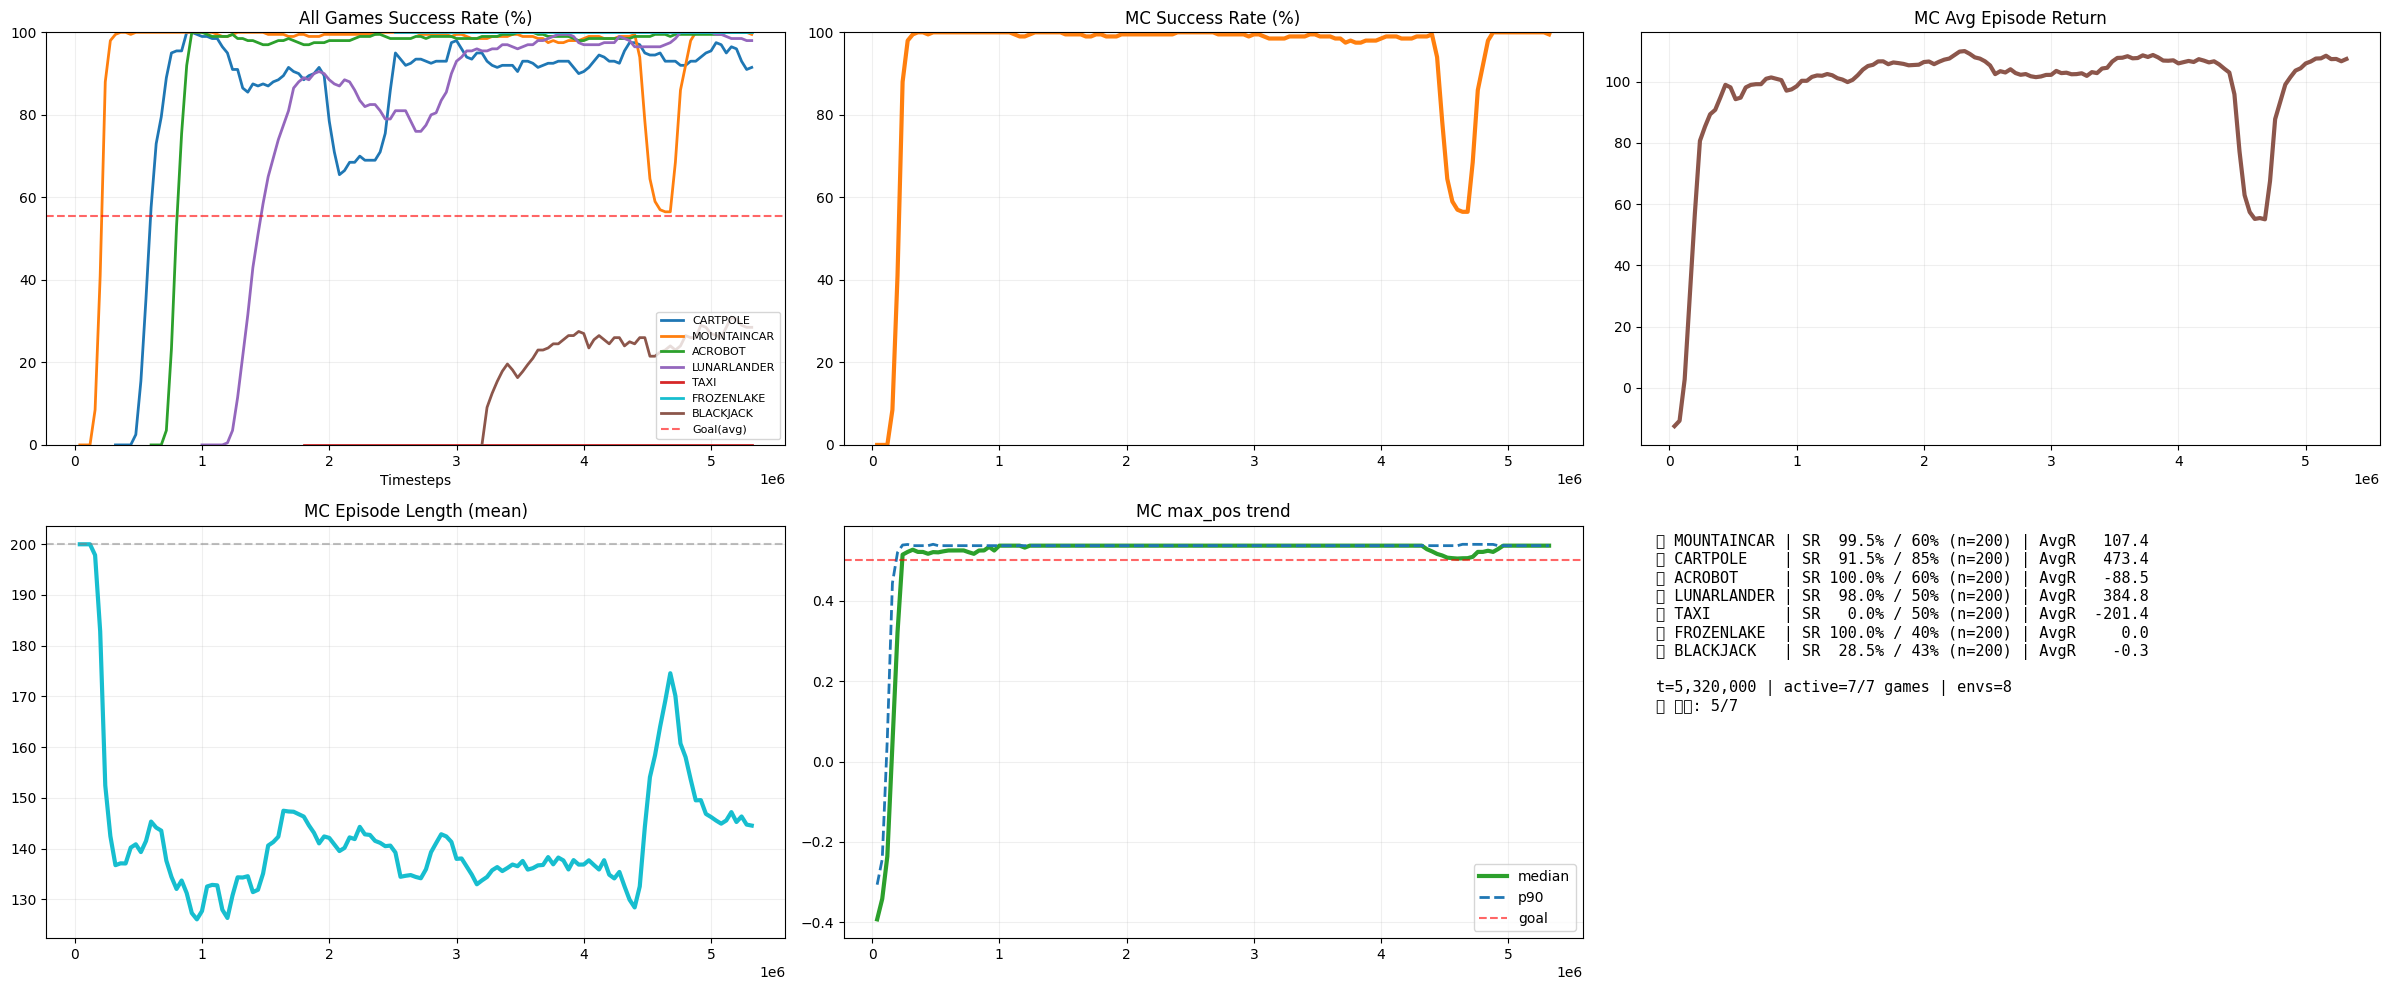


🛑 수동 중지!
💾 최종 저장: /content/drive/MyDrive/PingPing_Project/sb3_maskable_7games/ppo_7games_final.zip
num_ckpt=267, latest=/content/drive/MyDrive/PingPing_Project/sb3_maskable_7games/ppo_7games_980000_steps.zip
🐌 학습 완료!


In [ ]:
# ============================================================
# [셀 8/10] 자동 재개 학습 (7게임)
# ============================================================
def find_resume_target(save_dir):
    final = os.path.join(save_dir, "ppo_7games_final.zip")
    if os.path.exists(final):
        return final, 0, "final"
    cands = glob.glob(os.path.join(save_dir, "ppo_7games_*_steps.zip"))
    if not cands:
        return None, 0, "none"
    def parse(p):
        m = re.search(r"ppo_7games_(\d+)_steps\.zip$", os.path.basename(p))
        return int(m.group(1)) if m else -1
    cands.sort(key=parse)
    return cands[-1], parse(cands[-1]), "checkpoint"

def safe_close(e):
    try: e.close()
    except: pass

def fresh_env():
    if "vec_env" in globals():
        safe_close(globals()["vec_env"])
    e = DummyVecEnv([make_thunk(i) for i in range(N_ENVS)])
    e.reset()
    print(f"✅ DummyVecEnv + ActionMasker (n={N_ENVS})")
    return e

# ★ 넉넉하게 — 자고 일어나도 충분
ADD_TIMESTEPS = 20_000_000

vec_env = fresh_env()
path, steps, rtype = find_resume_target(SAVE_DIR)
print(f"🔎 resume: {path} | type={rtype} | steps={steps}")

if path is not None:
    try:
        model = MaskablePPO.load(path, env=vec_env, device="auto")
        print("🧠 이어서 학습합니다.")
    except ValueError as e:
        print(f"⚠️ 로드 실패: {e}")
        for f in glob.glob(os.path.join(SAVE_DIR, "ppo_7games_*.zip")):
            os.remove(f)
        model = MaskablePPO(
            "MlpPolicy", vec_env, verbose=0,
            n_steps=2048, batch_size=256,
            gamma=0.99, gae_lambda=0.95, n_epochs=10,
            learning_rate=lambda p: 3e-4 * p,
            clip_range=0.2, ent_coef=0.02,
            policy_kwargs=dict(net_arch=dict(pi=[256, 256], vf=[256, 256])),
            device="auto", seed=SEED,
        )
        print("🍼 새 모델 생성")
else:
    print("🍼 새 모델로 시작합니다.")
    model.set_env(vec_env)

ui_cb.last_log = 0
print(f"🏁 학습량: {ADD_TIMESTEPS:,} steps")
print(f"🎯 졸업 기준: {STOP_TARGETS}")
print("😴 전 게임 졸업하면 자동 종료됩니다. 편히 주무세요!")

try:
    model.learn(total_timesteps=ADD_TIMESTEPS, callback=callbacks, reset_num_timesteps=False)
except KeyboardInterrupt:
    print("\n🛑 수동 중지!")

final_path = os.path.join(SAVE_DIR, "ppo_7games_final")
model.save(final_path)
print("💾 최종 저장:", final_path + ".zip")

ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, "ppo_7games_*_steps.zip")))
print(f"num_ckpt={len(ckpts)}, latest={ckpts[-1] if ckpts else None}")

safe_close(vec_env)
print("🐌 학습 완료!")

In [ ]:
# ============================================================
# [셀 9/10] 졸업식 GIF (7게임)
# ============================================================
!pip -q install imageio opencv-python-headless
import cv2, imageio
from IPython.display import Image as IPyImage, display

MODEL_PATH = os.path.join(SAVE_DIR, "ppo_7games_final.zip")
model = MaskablePPO.load(MODEL_PATH, device="auto")
print("🎓 모델 로드:", MODEL_PATH)

# GIF 가능한 게임만 (blackjack은 렌더 불가)
gif_games = ["cartpole", "mountaincar", "acrobot", "lunarlander"]

capt_envs = {}
for g in gif_games:
    try:
        capt_envs[g] = make_env_safe(GAME_SPECS[g]["env_name"], render_mode="rgb_array")
    except:
        capt_envs[g] = make_env_safe("LunarLander-v2", render_mode="rgb_array")

states = {}
dones = {g: False for g in gif_games}
for g in gif_games:
    raw, _ = capt_envs[g].reset(seed=SEED)
    states[g] = build_obs(np.asarray(raw, dtype=np.float32), g)

frames = []
print("🎬 졸업 공연 촬영!")
for step in range(600):
    if all(dones.values()):
        break
    row = []
    for g in gif_games:
        frame = capt_envs[g].render()
        row.append(cv2.resize(frame, (500, 400)))
        if not dones[g]:
            mask = np.zeros(GLOBAL_ACTIONS, dtype=np.float32)
            spec = GAME_SPECS[g]
            mask[spec["action_offset"]:spec["action_offset"] + spec["num_actions"]] = 1.0
            action, _ = model.predict(states[g], deterministic=True, action_masks=mask.reshape(1, -1))
            action = int(action)
            local = action - spec["action_offset"]
            raw, _, term, trunc, _ = capt_envs[g].step(local)
            states[g] = build_obs(np.asarray(raw, dtype=np.float32), g)
            dones[g] = term or trunc
    frames.append(np.hstack(row))

for e in capt_envs.values():
    e.close()

gif_path = os.path.join(SAVE_DIR, "pingping_7games_graduation.gif")
imageio.mimsave(gif_path, frames, fps=30)
print("🎉 저장:", gif_path)
display(IPyImage(filename=gif_path))

In [ ]:
# ============================================================
# [셀 10/10] 체크포인트 확인
# ============================================================
def find_latest(save_dir):
    cands = glob.glob(os.path.join(save_dir, "ppo_7games_*_steps.zip"))
    if not cands: return None
    def s(p):
        m = re.search(r"(\d+)_steps", os.path.basename(p))
        return int(m.group(1)) if m else -1
    cands.sort(key=s)
    return cands[-1]

print("Latest:", find_latest(SAVE_DIR))
print("🐌 런타임 끊겨도 이어갈 수 있어요!")
print(f"🎯 졸업 기준: {STOP_TARGETS}")
print("😴 전 게임 졸업 시 자동 종료. 굿나잇!")

Latest: /content/drive/MyDrive/PingPing_Project/sb3_maskable_7games/ppo_7games_5340000_steps.zip
🐌 런타임 끊겨도 이어갈 수 있어요!
🎯 졸업 기준: {'cartpole': 0.85, 'mountaincar': 0.6, 'acrobot': 0.6, 'lunarlander': 0.5, 'taxi': 0.5, 'frozenlake': 0.4, 'blackjack': 0.43}
😴 전 게임 졸업 시 자동 종료. 굿나잇!
